In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys
sys.path.append("/home/z5297792/ESP_zonodo/") 
from functions import doppio_pipeliner   


In [25]:
width=500
x = np.linspace(-width // 2, width // 2, 101)
y = np.linspace(-width // 2, width // 2, 101)
X, Y = np.meshgrid(x, y, indexing='ij')

xc, yc = 0.0, 0.0
Q11, Q12, Q22 = 1, .4, 1
Omega = 0.03
Rc = 85.0 

# rescale Q to have unit determinant
Q = np.array([[Q11, Q12], [Q12, Q22]])
Q = Q / np.sqrt(np.linalg.det(Q))
q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]

dx, dy = X - xc, Y - yc
rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2
Qr2 = (q11*dx + q12*dy)**2 + (q12*dx + q22*dy)**2 # ||Qr||

u =  - Omega * (q12*dx + q22*dy) * np.exp( - rho2 / Rc**2 )
v =  + Omega * (q11*dx + q12*dy) * np.exp( - rho2 / Rc**2 ) 
w = Omega*(q11 + q22)


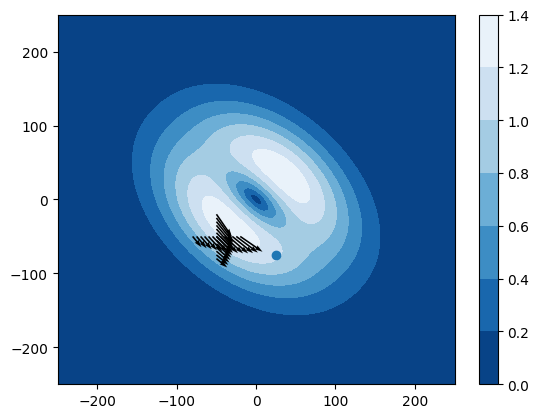

In [96]:
nxc, nyc = -50, -50
x1, y1, u1, v1, x2, y2, u2, v2 = doppio_pipeliner(nxc, nyc, u, v, X, Y, r=30)

plt.contourf(X, Y, np.hypot(u,v), cmap='Blues_r')
plt.colorbar()
plt.quiver(x1, y1, u1, v1, width=.004)
plt.quiver(x2, y2, u2, v2, width=.004)

plt.scatter(x[ic], y[jc])


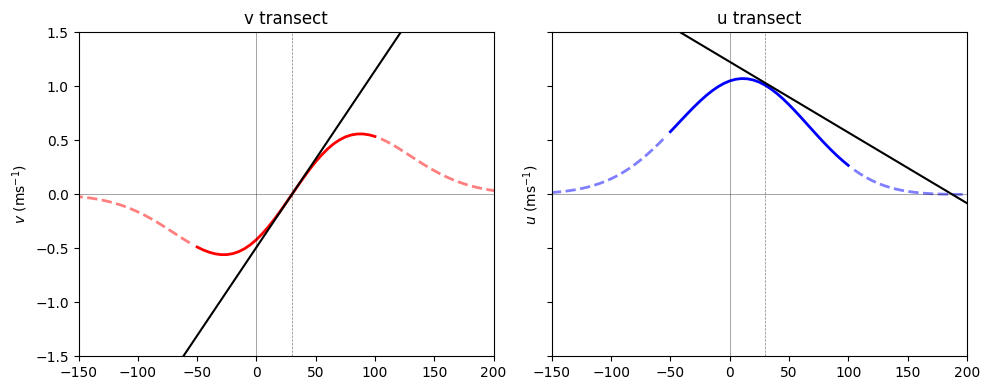

In [95]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

ic = 55
jc = 35
ul, vl = u[:, jc], v[:, jc]

mask = np.abs(x - x[ic]) < 80

# v transect
axs[0].plot(x[mask], vl[mask], 'r', lw=2)
axs[0].plot(
    np.where(~mask, x, np.nan),
    np.where(~mask, vl, np.nan),
    'r', ls='--', alpha=0.5, lw=2
)
axs[0].plot(
    x,
    0.5 * Omega * q11 * (x - (xc - q12/q11 * (y[jc] - yc))),
    'k'
)
axs[0].axhline(0, lw=0.5, color='k', alpha=0.5)
axs[0].axvline(0, lw=0.5, color='k', alpha=0.5)
axs[0].axvline(x0, lw=0.5, color='k', alpha=0.5, ls='--')
axs[0].set_ylabel(r'$v$ (ms$^{-1}$)')
axs[0].set_title('v transect')

# u transect
axs[1].plot(x[mask], ul[mask], 'b', lw=2)
axs[1].plot(
    np.where(~mask, x, np.nan),
    np.where(~mask, ul, np.nan),
    'b', ls='--', alpha=0.5, lw=2
)
axs[1].plot(
    x,
    0.5 * Omega * (-q12 * (x - xc) - q22 * (y[jc] - yc)),
    'k'
)
axs[1].axhline(0, lw=0.5, color='k', alpha=0.5)
axs[1].axvline(0, lw=0.5, color='k', alpha=0.5)
axs[1].axvline(x0, lw=0.5, color='k', alpha=0.5, ls='--')
axs[1].set_ylabel(r'$u$ (ms$^{-1}$)')
axs[1].set_title('u transect')

for ax in axs:
    ax.set_xlim(-150, 200)
    ax.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

